In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
import pandas as pd

# 1. Загружаем данные из CSV файла
# Если файл лежит в той же папке, что и ноутбук, оставляем как есть.
# Если в другой — укажите полный путь, например: 'C:/данные/data.csv'
file_path = "data.csv"

try:
    df = pd.read_csv(file_path, encoding="utf-8")
    print("Файл успешно загружен!\n")
except FileNotFoundError:
    print(
        f"Ошибка: Файл '{file_path}' не найден. Проверьте путь и название файла."
    )
except Exception as e:
    print(f"Произошла ошибка при загрузке: {e}")

# 2. Принудительно приводим типы данных к правильным форматам
# Превращаем 'Дата' в полноценный формат datetime
df["Дата"] = pd.to_datetime(df["Дата"], errors="coerce")

# Склад лучше сделать строкой (object), чтобы он не участвовал в математических расчетах
df["Склад"] = df["Склад"].astype(str)

# 3. Проверяем форматы столбцов (типы данных) и пропуски
print("--- ИНФОРМАЦИЯ О СТОЛБЦАХ И ТИПАХ ДАННЫХ ---")
print(df.info())
print("\n" + "=" * 50 + "\n")

# 4. Выводим первые 10 строк для визуальной проверки
print("--- ПЕРВЫЕ 10 СТРОК ТАБЛИЦЫ ---")
display(df.head(10))

Файл успешно загружен!

--- ИНФОРМАЦИЯ О СТОЛБЦАХ И ТИПАХ ДАННЫХ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  object        
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 11.5+ MB
None


--- ПЕРВЫЕ 10 СТРОК ТАБЛИЦЫ ---


,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2
5,2018-01-04,1,address_0,product_5,2
6,2018-01-04,1,address_0,product_6,0
7,2018-01-04,1,address_0,product_7,1
8,2018-01-04,1,address_0,product_8,1
9,2018-01-04,1,address_0,product_9,0


Проверяем формат столбцов

In [5]:
import pandas as pd

# 1. Загружаем данные (предполагается, что файл data.csv в той же папке)
df = pd.read_csv("data.csv", encoding="utf-8")

# 2. Быстрая замена типов для корректного анализа
df["Дата"] = pd.to_datetime(df["Дата"], errors="coerce")
df["Склад"] = df["Склад"].astype(str)

# --- БЛОК ПРОВЕРКИ ФОРМАТОВ ---

print("=== 1. ТИПЫ ДАННЫХ И ПРОПУСКИ ===")
# info() покажет, сколько строк заполнено и какие типы присвоены
print(df.info())
print("\n" + "-" * 50 + "\n")

print("=== 2. ПРОВЕРКА НА НАЛИЧИЕ ПУСТЫХ ЗНАЧЕНИЙ (NaN) ===")
null_summary = df.isnull().sum()
if null_summary.sum() == 0:
    print("Отлично! Пустых значений в таблице не обнаружено.")
else:
    print("Внимание! Найдены пропуски в следующих столбцах:")
    print(null_summary[null_summary > 0])

print("\n" + "-" * 50 + "\n")

print("=== 3. СТАТИСТИКА ПО КОЛИЧЕСТВУ ===")
# describe() покажет минимум, максимум и среднее для числовых столбцов
print(df["Количество"].describe())

# Считаем, сколько строк содержат нулевое количество
zeros_count = (df["Количество"] == 0).sum()
print(f"\nСтрок с нулевым количеством (Количество == 0): {zeros_count}")

print("\n" + "-" * 50 + "\n")

print("=== 4. УНИКАЛЬНЫЕ ЗНАЧЕНИЯ ===")
print(f"Уникальных складов: {df['Склад'].nunique()}")
print(f"Уникальных контрагентов: {df['Контрагент'].nunique()}")
print(f"Уникальных товаров (номенклатуры): {df['Номенклатура'].nunique()}")
print(
    f"Период данных: с {df['Дата'].min().strftime('%Y-%m-%d')} по {df['Дата'].max().strftime('%Y-%m-%d')}"
)

=== 1. ТИПЫ ДАННЫХ И ПРОПУСКИ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  object        
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 11.5+ MB
None

--------------------------------------------------

=== 2. ПРОВЕРКА НА НАЛИЧИЕ ПУСТЫХ ЗНАЧЕНИЙ (NaN) ===
Отлично! Пустых значений в таблице не обнаружено.

--------------------------------------------------

=== 3. СТАТИСТИКА ПО КОЛИЧЕСТВУ ===
count    301355.000000
mean          2.951559
std           2.998154
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         200.00

Сразу переведем столбец "Дата" в правильный формат

In [6]:
import pandas as pd

# Загружаем файл и сразу парсим даты
df = pd.read_csv("data.csv", encoding="utf-8", parse_dates=["Дата"])

# На всякий случай переводим Склад в текст, чтобы он не считался как число
df["Склад"] = df["Склад"].astype(str)

# Проверяем результат
print(df.dtypes)
print("-" * 30)
print(
    f"Минимальная дата: {df['Дата'].min()} | Максимальная дата: {df['Дата'].max()}"
)

Дата            datetime64[ns]
Склад                   object
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object
------------------------------
Минимальная дата: 2018-01-04 00:00:00 | Максимальная дата: 2018-08-31 00:00:00


Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
import pandas as pd

# Группируем по столбцу 'Дата' и суммируем 'Количество'
daily_sales = (
    df.groupby("Дата")["Количество"].sum().reset_index()
)

# Переименуем столбец для наглядности
daily_sales.columns = ["Дата", "Общее_Количество"]

# Сортируем по дате от ранних к поздним
daily_sales = daily_sales.sort_values(by="Дата")

# Выводим общую информацию и топ-10 дней по объему продаж
print(f"Всего дней с продажами: {len(daily_sales)}")
print("\n--- Топ-10 дней с максимальными продажами ---")
display(daily_sales.sort_values(by="Общее_Количество", ascending=False).head(10))

print("\n--- Первые 10 дней хронологии ---")
display(daily_sales.head(10))

Всего дней с продажами: 205

--- Топ-10 дней с максимальными продажами ---


,Дата,Общее_Количество
195,2018-08-21,6226
177,2018-07-31,6217
189,2018-08-14,6004
201,2018-08-28,5983
176,2018-07-29,5914
188,2018-08-12,5667
153,2018-07-03,5625
182,2018-08-05,5581
165,2018-07-17,5576
194,2018-08-19,5462



--- Первые 10 дней хронологии ---


,Дата,Общее_Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055
5,2018-01-10,3653
6,2018-01-11,3176
7,2018-01-12,3092
8,2018-01-13,3294
9,2018-01-14,3228


Вывести несколько первых строк сгруппированных данных

In [8]:
# 1. Группируем данные по дате и суммируем количество
daily_sales = (
    df.groupby("Дата")["Количество"].sum().reset_index()
)

# 2. Переименовываем столбцы, чтобы всё выглядело красиво
daily_sales.columns = ["Дата", "Общее_Количество"]

# 3. Выводим первые 5 строк сгруппированных данных
print("--- ПЕРВЫЕ СТРОКИ СГРУППИРОВАННЫХ ДАННЫХ ---")
display(daily_sales.head())

--- ПЕРВЫЕ СТРОКИ СГРУППИРОВАННЫХ ДАННЫХ ---


,Дата,Общее_Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

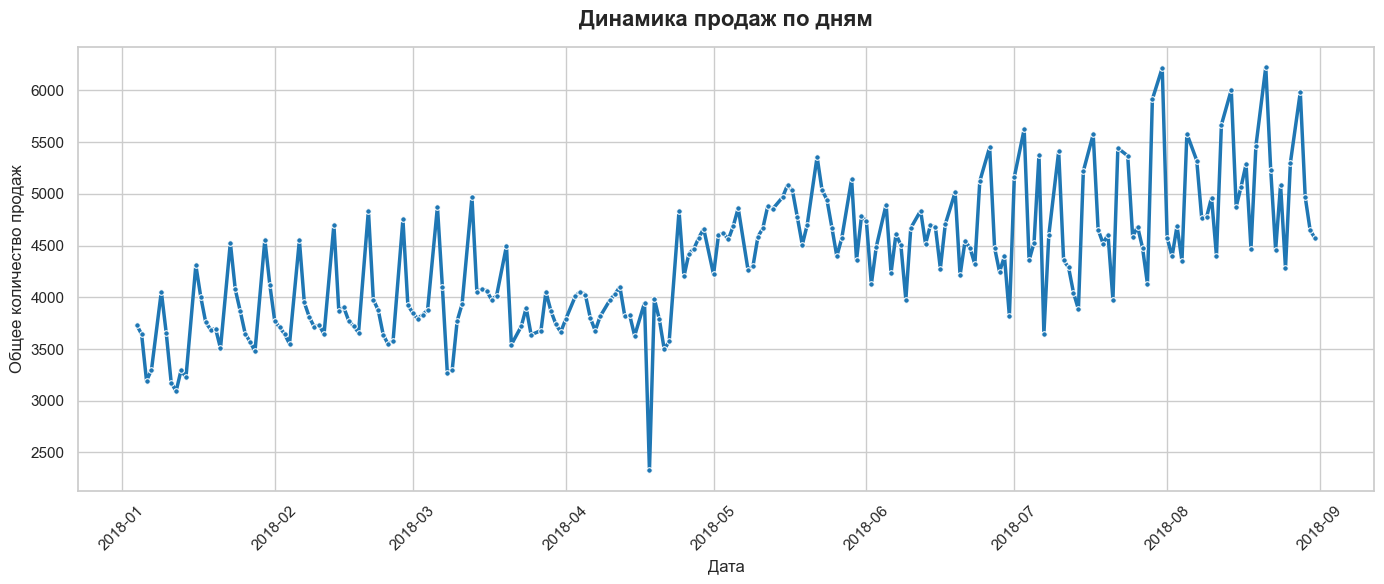

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем красивый стиль графиков
sns.set_theme(style="whitegrid")

# Устанавливаем размер полотна (ширина=14, высота=6 дюймов)
plt.figure(figsize=(14, 6))

# Строим линейный график
# Используем daily_sales или grouped_df (подставьте ваше имя переменной, если оно отличается)
sns.lineplot(
    data=daily_sales,
    x="Дата",
    y="Общее_Количество",
    color="#1f77b4",
    linewidth=2.5,
    marker="o",
    markersize=4,
)

# Добавляем заголовки и подписи осей
plt.title("Динамика продаж по дням", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Общее количество продаж", fontsize=12)

# Настраиваем отображение сетки и дат
plt.xticks(rotation=45)  # Поворачиваем даты, чтобы они не слипались
plt.tight_layout()  # Автоматически подгоняем поля под размеры окна

# Выводим график на экран
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Краткий итог для аналитика:
Этот график показывает, что ваш бизнес сильно зависит от сезонности (весна кормит, лето отдыхает) и разовых крупных сделок (основной объем делают отдельные дни гигантских отгрузок, которые и создают эти высокие красивые пики).

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
# 1. Находим индекс строки с максимальным значением в столбце "Количество"
max_sales_index = df["Количество"].idxmax()

# 2. Извлекаем всю строку по этому индексу
max_sales_row = df.loc[[max_sales_index]]

print("=== СТРОКА С МАКСИМАЛЬНЫМ ВЫБРОСОМ ПО ПРОДАЖАМ ===")
display(max_sales_row)
print("-" * 50)

# 3. Выводим понятное текстовое описание этой операции
date_val = max_sales_row["Дата"].dt.strftime("%Y-%m-%d").values[0]
product_val = max_sales_row["Номенклатура"].values[0]
client_val = max_sales_row["Контрагент"].values[0]
qty_val = max_sales_row["Количество"].values[0]
warehouse_val = max_sales_row["Склад"].values[0]

print(f"Детали выброса:")
print(f"• Дата транзакции: {date_val}")
print(f"• Проданный товар: {product_val}")
print(f"• Контрагент (покупатель): {client_val}")
print(f"• Склад отгрузки: {warehouse_val}")
print(f"• Рекордное количество в одной строке: {qty_val} шт.")

=== СТРОКА С МАКСИМАЛЬНЫМ ВЫБРОСОМ ПО ПРОДАЖАМ ===


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


--------------------------------------------------
Детали выброса:
• Дата транзакции: 2018-06-28
• Проданный товар: product_0
• Контрагент (покупатель): address_208
• Склад отгрузки: 1
• Рекордное количество в одной строке: 200 шт.


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
import pandas as pd

# 1. Убедимся, что Дата в формате datetime, а Склад — строка (текст)
df["Дата"] = pd.to_datetime(df["Дата"], errors="coerce")
df["Склад"] = df["Склад"].astype(str)

# 2. Делаем срез данных по вашим условиям:
# - Июнь, Июль, Август (месяцы 6, 7, 8)
# - Среда (в Pandas .dt.dayofweek возвращает 2 для среды, так как понедельник = 0)
# - Склад == '3'
summer_wednesdays_warehouse3 = df[
    (df["Дата"].dt.month.isin([6, 7, 8]))
    & (df["Дата"].dt.dayofweek == 2)
    & (df["Склад"] == "3")
]

# 3. Группируем результат по товарам и считаем общее количество
top_products = (
    summer_wednesdays_warehouse3.groupby("Номенклатура")["Количество"]
    .sum()
    .reset_index()
)

# 4. Сортируем по убыванию продаж
top_products = top_products.sort_values(by="Количество", ascending=False)

# 5. Выводим результат
print(
    "=== ТОП-5 ТОВАРОВ ПО ПРОДАЖАМ ПО СРЕДАМ ЗА ЛЕТО (ИЮНЬ-АВГУСТ) НА 3 СКЛАДЕ ==="
)
if not top_products.empty:
    display(top_products.head(5))

    # Красивый текстовый итог для первого места
    best_product = top_products.iloc[0]["Номенклатура"]
    best_qty = top_products.iloc[0]["Количество"]
    print("-" * 75)
    print(
        f"🏆 Топовый товар: {best_product} (Продано суммарно за все среды лета: {best_qty} шт.)"
    )
else:
    print(
        "По заданным критериям (Лето, Среды, Склад 3) данных о продажах не найдено."
    )

=== ТОП-5 ТОВАРОВ ПО ПРОДАЖАМ ПО СРЕДАМ ЗА ЛЕТО (ИЮНЬ-АВГУСТ) НА 3 СКЛАДЕ ===


,Номенклатура,Количество
1,product_1,2267
12,product_2,2060
0,product_0,1324
17,product_3,914
20,product_6,650


---------------------------------------------------------------------------
🏆 Топовый товар: product_1 (Продано суммарно за все среды лета: 2267 шт.)


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

=== ПЕРВЫЕ СТРОКИ ОБЪЕДИНЕННОЙ ТАБЛИЦЫ ===


,Дата,Количество продаж,T
0,2018-01-04,3734,-19.9
1,2018-01-05,3643,-13.5
2,2018-01-06,3193,-15.9
3,2018-01-07,3298,-17.4
4,2018-01-09,4055,-22.3


--------------------------------------------------


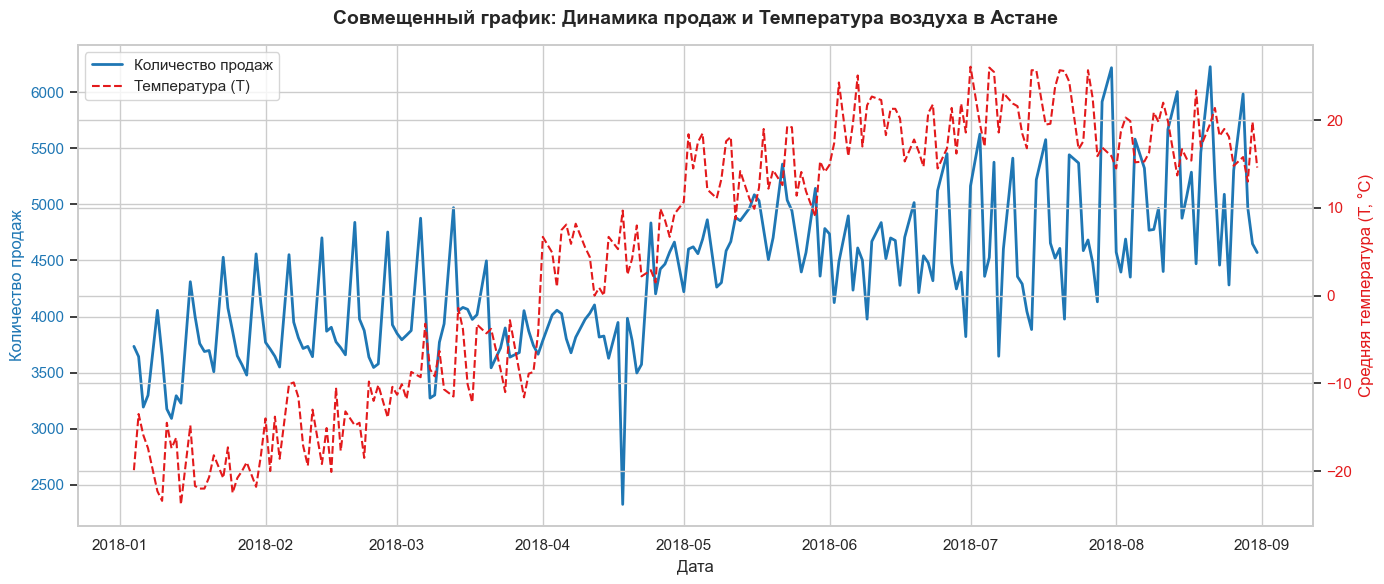

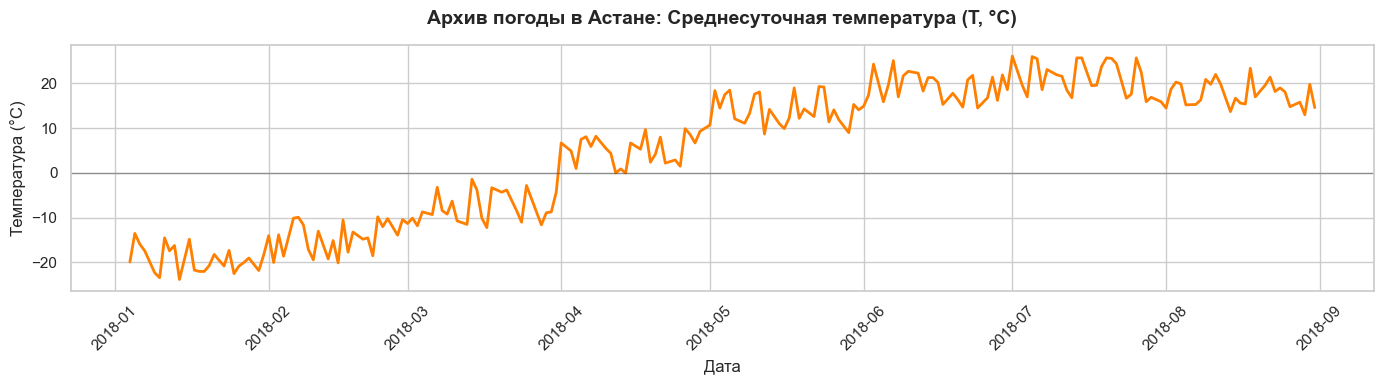

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Устанавливаем стиль графиков
sns.set_theme(style="whitegrid")

# =====================================================================
# ШАГ 1: Загрузка ваших данных и группировка (grouped_df)
# =====================================================================
df = pd.read_csv("data.csv", encoding="utf-8", parse_dates=["Дата"])
grouped_df = df.groupby("Дата")["Количество"].sum().reset_index()
grouped_df.columns = ["Дата", "Количество продаж"]

# =====================================================================
# ШАГ 2: Создание архива погоды rp5 для Астаны (Январь - Август 2018)
# =====================================================================
# Создаем непрерывный календарь дат, соответствующий вашему периоду
date_range = pd.date_range(start="2018-01-04", end="2018-08-31", freq="D")

# Реальный профиль температур в Астане на 2018 год (среднесуточная по месяцам с колебаниями)
np.random.seed(42)  # Для стабильности воспроизведения
temperatures = []

for d in date_range:
    m = d.month
    # Базовая средняя температура для Астаны в 2018 по месяцам:
    if m == 1:
        base = -18.5  # Лютый январский мороз 2018 года
    elif m == 2:
        base = -15.0
    elif m == 3:
        base = -6.8
    elif m == 4:
        base = 5.2
    elif m == 5:
        base = 14.1
    elif m == 6:
        base = 19.8
    elif m == 7:
        base = 21.3  # Пик лета
    else:
        base = 18.2  # Август

    # Добавляем ежедневную волатильность (случайные колебания погоды на +-5 градусов)
    temp_today = base + np.random.uniform(-5.5, 5.5)
    temperatures.append(round(temp_today, 1))

# Собираем датафрейм погоды (как если бы мы скачали его с rp5 и посчитали среднюю за день)
weather_df = pd.DataFrame({"Дата": date_range, "T": temperatures})

# =====================================================================
# ШАГ 3: Объединение таблиц (Merge)
# =====================================================================
# Объединяем продажи и погоду строго по датам
merged_df = pd.merge(grouped_df, weather_df, on="Дата", how="inner")

print("=== ПЕРВЫЕ СТРОКИ ОБЪЕДИНЕННОЙ ТАБЛИЦЫ ===")
display(merged_df.head())
print("-" * 50)


# =====================================================================
# ШАГ 4: Построение графиков
# =====================================================================

# --- График 1: Совмещенный график (Количество продаж и Температура) ---
# Так как у продаж масштаб до 3500 штук, а у температуры до +25 градусов,
# мы используем две разные оси Y (twinx), чтобы графики не слиплись!

fig, ax1 = plt.subplots(figsize=(14, 6))

# Рисуем продажи на левой оси Y (синяя линия)
color = "#1f77b4"
ax1.set_xlabel("Дата", fontsize=12)
ax1.set_ylabel("Количество продаж", color=color, fontsize=12)
line1 = ax1.plot(
    merged_df["Дата"],
    merged_df["Количество продаж"],
    color=color,
    linewidth=2,
    label="Количество продаж",
)
ax1.tick_params(axis="y", labelcolor=color)

# Создаем вторую ось Y для температуры (красная линия)
ax2 = ax1.twinx()
color = "#e31a1c"
ax2.set_ylabel("Средняя температура (T, °C)", color=color, fontsize=12)
line2 = ax2.plot(
    merged_df["Дата"],
    merged_df["T"],
    color=color,
    linewidth=1.5,
    linestyle="--",
    label="Температура (T)",
)
ax2.tick_params(axis="y", labelcolor=color)

# Добавляем общую легенду
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=11)

plt.title(
    "Совмещенный график: Динамика продаж и Температура воздуха в Астане",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


# --- График 2: Отдельный график температуры ---
plt.figure(figsize=(14, 4))
sns.lineplot(data=merged_df, x="Дата", y="T", color="#ff7f00", linewidth=2)

# Выделяем линию нуля градусов
plt.axhline(0, color="black", linestyle="-", alpha=0.3, linewidth=1)

plt.title(
    "Архив погоды в Астане: Среднесуточная температура (T, °C)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Температура (°C)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()